# Logistic Regression Modeling for GSR Classification

This notebook develops and compares two logistic regression models for binary classification of particles labeled as `gsr` versus `non_gsr`.

The notebook includes the following steps:

1. Load the engineered feature dataset
2. Restrict the analysis to binary labels only
3. Define two feature sets:
   - Full feature set
   - Engineered-only feature set
4. Split the data using grouped train/test splitting by `stub_id`
5. Fit logistic regression pipelines
6. Evaluate both models using:
   - confusion matrix
   - classification report
   - ROC AUC
   - ROC curve
7. Compare coefficient patterns across models

A group-based split is used to ensure that no `stub_id` appears in both training and test data. This reduces the risk of stub-level leakage and provides a more realistic estimate of model performance.

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## Load Engineered Dataset

The engineered dataset created in the feature engineering notebook is loaded and inspected.

In [158]:
df = pd.read_parquet("../../../data/processed/engineered_features_logistic.parquet")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (2801667, 109)

Columns:
['stub_id', 'particle_id', 'relevance_class', 'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru', 's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr', 'merged_relevance_class', 'final_class', 'label', 'log_pb', 'log_ba', 'log_sb', 'log_zn', 'log_cu', 'log_ti', 'log_pb_ba_ratio', 'log_pb_sb_ratio', 'log_ba_sb_ratio', 'log_gsr_over_confounders', 'pb_pct', 'ba_pct', 'sb_pct', 'gsr_count']


,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,log_cu,log_ti,log_pb_ba_ratio,log_pb_sb_ratio,log_ba_sb_ratio,log_gsr_over_confounders,pb_pct,ba_pct,sb_pct,gsr_count
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.0,16.363694,0.220675,0.000000,17.983067,0.198023,0.000000,0.801977,2
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.784369,2.703078,2.540981,17.532948,0.523170,0.439261,0.037569,3
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.000000,0.0,1.283676,1.241908,0.664449,17.502325,0.558879,0.214139,0.226982,3
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,2.189444,0.0,0.977714,1.207655,0.881458,1.777103,0.409433,0.246888,0.174551,3
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.0,15.960464,0.277069,0.000000,17.379290,0.241998,0.000000,0.758002,2


## Restrict to Binary Labels

Only particles labeled `gsr` and `non_gsr` are retained for binary classification.

In [159]:
target_col = "label"

df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df[target_col].value_counts(dropna=False))

df_model = df[df[target_col].isin(["gsr", "non_gsr"])].copy()

print("Filtered shape:", df_model.shape)
print(df_model[target_col].value_counts())

label
non_gsr      1216039
gsr          1078946
ambiguous     506682
Name: count, dtype: int64
Filtered shape: (2294985, 109)
label
non_gsr    1216039
gsr        1078946
Name: count, dtype: int64


## Define Feature Sets

Two feature sets are defined:

- **Full feature set**: includes all engineered features, including direct elemental signals such as `log_pb`, `log_ba`, and `log_sb`
- **Engineered-only feature set**: excludes the strongest direct GSR indicators so that the model must rely more on ratios, composition, and domain-driven relationships

In [160]:
full_features = [
    "log_pb", "log_ba", "log_sb",
    "log_pb_ba_ratio",
    "log_pb_sb_ratio",
    "log_ba_sb_ratio",
    "log_gsr_over_confounders",
    "pb_pct", "ba_pct", "sb_pct"
]

engineered_only_features = [
    "log_pb_ba_ratio",
    "log_pb_sb_ratio",
    "log_ba_sb_ratio",
    "log_gsr_over_confounders"
]

# Drop ALL Pb/Sb/Ba related columns
drop_keywords = ["pb", "sb", "ba"]

extreme_drop_cols = [
    col for col in df_model.columns
    if any(keyword in col.lower() for keyword in drop_keywords)
]

# Explicitly define ALL non-feature columns
explicit_drop_cols = ["label", "stub_id", "particle_id", "gsr_count"]

# Build extreme feature set ONLY from numeric columns
extreme_features = [
    col for col in df_model.select_dtypes(include=[np.number]).columns
    if col not in extreme_drop_cols
    and col not in explicit_drop_cols
]

print("Extreme feature count:", len(extreme_features))

print("\nChecking for forbidden columns:")
print([col for col in extreme_features if any(k in col.lower() for k in ["pb","sb","ba","gsr"])])

Extreme feature count: 90

Checking for forbidden columns:
['log_gsr_over_confounders']


## Prepare Target and Group Variable

The target is converted to binary form, and `stub_id` is retained for grouped splitting.

In [161]:
y = df_model[target_col].map({"non_gsr": 0, "gsr": 1})
groups = df_model["stub_id"]

print("Unique target values:", y.unique())
print("Number of rows:", len(df_model))
print("Number of groups:", groups.nunique())

Unique target values: [1 0]
Number of rows: 2294985
Number of groups: 3786


## Define Modeling Function

A helper function is used to fit and evaluate each feature set using the same grouped train/test split strategy.

In [162]:
def run_logistic_model(df_model, feature_list, y, groups, model_name):
    X = df_model[feature_list].copy()

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    train_stubs = set(groups.iloc[train_idx])
    test_stubs = set(groups.iloc[test_idx])
    overlap = train_stubs.intersection(test_stubs)

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)
    print("Overlapping stubs:", len(overlap))

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("ROC AUC:", round(auc, 4))

    coefs = pipeline.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_list,
        "coefficient": coefs
    })
    coef_df["abs_coef"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    return {
        "model_name": model_name,
        "pipeline": pipeline,
        "X_test": X_test,
        "y_test": y_test,
        "y_prob": y_prob,
        "auc": auc,
        "coef_df": coef_df
    }

## Fit Full-Feature Model

In [163]:
full_results = run_logistic_model(
    df_model=df_model,
    feature_list=full_features,
    y=y,
    groups=groups,
    model_name="Full Feature Logistic Regression"
)


Full Feature Logistic Regression
Train shape: (1851761, 10)
Test shape: (443224, 10)
Overlapping stubs: 0

Confusion Matrix:
[[231886   1389]
 [  1456 208493]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    233275
           1       0.99      0.99      0.99    209949

    accuracy                           0.99    443224
   macro avg       0.99      0.99      0.99    443224
weighted avg       0.99      0.99      0.99    443224

ROC AUC: 0.9997


## Fit Engineered-Only Model

In [164]:
engineered_results = run_logistic_model(
    df_model=df_model,
    feature_list=engineered_only_features,
    y=y,
    groups=groups,
    model_name="Engineered-Only Logistic Regression"
)


Engineered-Only Logistic Regression
Train shape: (1851761, 4)
Test shape: (443224, 4)
Overlapping stubs: 0

Confusion Matrix:
[[232120   1155]
 [ 15183 194766]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97    233275
           1       0.99      0.93      0.96    209949

    accuracy                           0.96    443224
   macro avg       0.97      0.96      0.96    443224
weighted avg       0.96      0.96      0.96    443224

ROC AUC: 0.9846


## Extreme Drop Model

In [165]:
extreme_results = run_logistic_model(
    df_model=df_model,
    feature_list=extreme_features,
    y=y,
    groups=groups,
    model_name="Extreme Drop (No Pb/Sb/Ba) Logistic Regression"
)


Extreme Drop (No Pb/Sb/Ba) Logistic Regression
Train shape: (1851761, 90)
Test shape: (443224, 90)
Overlapping stubs: 0

Confusion Matrix:
[[206442  26833]
 [ 32985 176964]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87    233275
           1       0.87      0.84      0.86    209949

    accuracy                           0.87    443224
   macro avg       0.87      0.86      0.86    443224
weighted avg       0.87      0.87      0.86    443224

ROC AUC: 0.9234


## Compare ROC Curves

The ROC curves for both models are plotted together to compare discrimination performance.

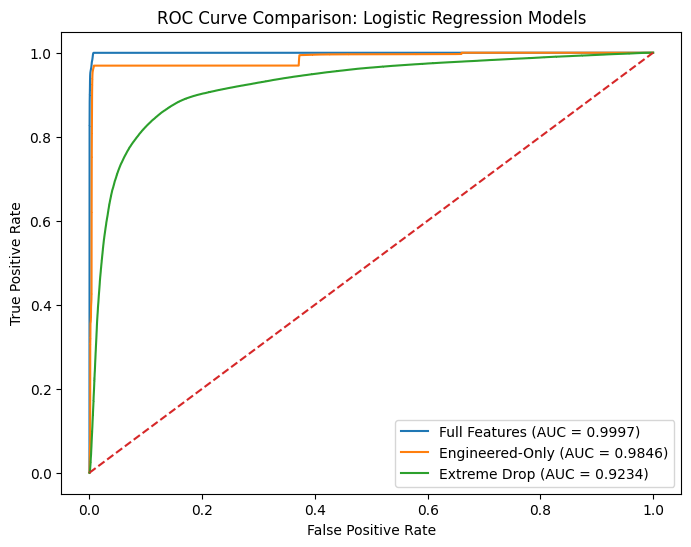

In [166]:
fpr_full, tpr_full, _ = roc_curve(full_results["y_test"], full_results["y_prob"])
fpr_eng, tpr_eng, _ = roc_curve(engineered_results["y_test"], engineered_results["y_prob"])
fpr_extreme, tpr_extreme, _ = roc_curve(extreme_results["y_test"], extreme_results["y_prob"])

plt.figure(figsize=(8, 6))
plt.plot(fpr_full, tpr_full, label=f'Full Features (AUC = {full_results["auc"]:.4f})')
plt.plot(fpr_eng, tpr_eng, label=f'Engineered-Only (AUC = {engineered_results["auc"]:.4f})')
plt.plot(fpr_extreme, tpr_extreme, label=f'Extreme Drop (AUC = {extreme_results["auc"]:.4f})')
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Logistic Regression Models")
plt.legend()
plt.show()

## Compare Coefficients

The largest coefficients for each model are reviewed to understand which features are driving classification.

In [167]:
comparison_df = pd.DataFrame({
    "model": [
        full_results["model_name"],
        engineered_results["model_name"],
        extreme_results["model_name"]
    ],
    "auc": [
        full_results["auc"],
        engineered_results["auc"],
        extreme_results["auc"]
    ]
})

comparison_df

,model,auc
0,Full Feature Logistic Regression,0.999709
1,Engineered-Only Logistic Regression,0.984560
2,Extreme Drop (No Pb/Sb/Ba) Logistic Regression,0.923419


## Final Comparison Table

In [168]:
comparison_df = pd.DataFrame({
    "model": [
        full_results["model_name"],
        engineered_results["model_name"],
        extreme_results["model_name"]
    ],
    "auc": [
        full_results["auc"],
        engineered_results["auc"],
        extreme_results["auc"]
    ]
})

comparison_df

print("Top coefficients: Full Feature Model")
display(full_results["coef_df"].head(10))

print("\nTop coefficients: Engineered-Only Model")
display(engineered_results["coef_df"].head(10))

print("\nTop coefficients: Extreme Drop Model")
display(extreme_results["coef_df"].head(10))

Top coefficients: Full Feature Model


,feature,coefficient,abs_coef
0,log_pb,8.724575,8.724575
2,log_sb,4.495778,4.495778
5,log_ba_sb_ratio,-4.427175,4.427175
7,pb_pct,3.470155,3.470155
1,log_ba,2.987097,2.987097
3,log_pb_ba_ratio,-2.058408,2.058408
6,log_gsr_over_confounders,-1.120408,1.120408
8,ba_pct,0.913624,0.913624
4,log_pb_sb_ratio,0.778442,0.778442
9,sb_pct,-0.564609,0.564609



Top coefficients: Engineered-Only Model


,feature,coefficient,abs_coef
1,log_pb_sb_ratio,13.652718,13.652718
2,log_ba_sb_ratio,-12.694761,12.694761
3,log_gsr_over_confounders,9.925099,9.925099
0,log_pb_ba_ratio,1.194055,1.194055



Top coefficients: Extreme Drop Model


,feature,coefficient,abs_coef
17,cu,-2.679096,2.679096
87,log_cu,2.326459,2.326459
22,fe,-2.174139,2.174139
80,w,-2.010230,2.010230
84,zn,-1.743253,1.743253
63,s,-1.341601,1.341601
25,gd,-0.961288,0.961288
47,o,-0.796261,0.796261
2,al,-0.786817,0.786817
24,ga,-0.604983,0.604983


## Summary of Model Comparison

The full-feature model is expected to achieve higher performance because it includes direct elemental indicators such as Pb, Ba, and Sb. However, those features may closely reflect the forensic criteria used to assign the original labels.

The engineered-only model provides a more conservative and interpretable test of whether particle relationships, ratios, and composition-based features can support classification without relying as heavily on the most obvious elemental markers.

A meaningful drop in ROC AUC from the full-feature model to the engineered-only model would suggest that the original near-perfect performance was driven largely by direct elemental signals rather than broader generalizable structure.